# Streamflow Data Retrieval
This notebook processes historical streamflow data for the North Fork Nooksack River (USGS Gauge 12205000) to evaluate how glacial retreat and climate variability are altering downstream water availability.

## Objectives
1. Fetch 40 years of daily discharge data (1984–2024) using the dataretrieval library (NWIS).
2. Convert volumetric flow units (cfs to cms) and generate rolling 7-day averages to smooth high-frequency variability.
3. Use time-series decomposition to isolate long-term trends from seasonal cycles and quantify shifts in peak melt-flow timing via linear regression.

## Data Sources
- [USGS National Water Information System (NWIS)](https://waterdata.usgs.gov/nwis/uv?site_no=12205000&legacy=1) 
- Site: North Fork Nooksack River below Cascade Creek near Glacier, WA (Gauge 12205000)

Output:
`data/streamflow_melt_season.csv`

# Environment Setup

In [1]:
# import libraries
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

# Study Area: Northfork Nooksack River Streamflow Data

## Streamflow Data Retrieval


In [2]:
#!pip install dataretrieval
import dataretrieval.nwis as nwis

### Fetch Daily Discharge Data


In [3]:
# parameters
site_id = '12205000' # NF Nooksack River BL Cascade Creek NR Glacier, WA
parameter_code = '00060' # Discharge, cubic feet per second (cfs)
start_date = '1984-01-01'
end_date = '2024-12-31'

df_usgs = nwis.get_record(sites=site_id, service='dv', start=start_date, end=end_date, parameterCd=parameter_code)

In [4]:
site_id = '12205000'
p_code = '00060' # Discharge
start = '1984-01-01'
end = '2024-12-31'

try:

    df_usgs, metadata = nwis.get_dv(sites=site_id, parameterCd=p_code, start=start, end=end)

    df_usgs.index = pd.to_datetime(df_usgs.index)
    df_usgs = df_usgs.rename(columns={'00060_Mean': 'discharge_cfs'})

    print(f"Captured {len(df_usgs)} rows")
except Exception as e:
    print(f"Data retrieval failed")

Captured 14976 rows


## Data Cleaning and Preparation

### Initial EDA

In [5]:
# display first 5 rows
df_usgs.head()

,site_no,discharge_cfs,00060_Mean_cd
datetime,,,
1984-01-01 00:00:00+00:00,12205000,280.0,A
1984-01-02 00:00:00+00:00,12205000,820.0,A
1984-01-03 00:00:00+00:00,12205000,1540.0,A
1984-01-04 00:00:00+00:00,12205000,7500.0,A
1984-01-05 00:00:00+00:00,12205000,2960.0,A


In [6]:
# reset index
df_usgs = df_usgs.reset_index()

# display info
df_usgs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14976 entries, 0 to 14975
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   datetime       14976 non-null  datetime64[ns, UTC]
 1   site_no        14976 non-null  object             
 2   discharge_cfs  14976 non-null  float64            
 3   00060_Mean_cd  14976 non-null  object             
dtypes: datetime64[ns, UTC](1), float64(1), object(2)
memory usage: 468.1+ KB


In [7]:
# check nulls
df_usgs.isnull().sum()

datetime         0
site_no          0
discharge_cfs    0
00060_Mean_cd    0
dtype: int64

In [8]:
# check duplicates for timeseries data
df_usgs.duplicated().sum()

np.int64(0)

### Column Renaming and Time Handling

In [9]:
# rename columns
# q_cfs = rate of discharge (water flow) in cubic feet per second
df_usgs.rename(columns={'discharge_cfs': 'q_cfs', 'datetime': 'date'}, inplace=True)

# remove timezone
df_usgs['date'] = pd.to_datetime(df_usgs['date']).dt.tz_localize(None)

## Feature Engineering

### Rolling Discharge Metrics

In [10]:
# calculate 7-day rolling mean
df_usgs['q_7d_roll_cfs'] = df_usgs['q_cfs'].rolling(window=7).mean()
df_usgs.head(10)

,date,site_no,q_cfs,00060_Mean_cd,q_7d_roll_cfs
0,1984-01-01,12205000,280.0,A,NaN
1,1984-01-02,12205000,820.0,A,NaN
2,1984-01-03,12205000,1540.0,A,NaN
3,1984-01-04,12205000,7500.0,A,NaN
4,1984-01-05,12205000,2960.0,A,NaN
5,1984-01-06,12205000,1840.0,A,NaN
6,1984-01-07,12205000,1590.0,A,2361.428571
7,1984-01-08,12205000,1400.0,A,2521.428571
8,1984-01-09,12205000,1040.0,A,2552.857143
9,1984-01-10,12205000,912.0,A,2463.142857


### Melt Season Filtering (Aug-Sept)
Late summer (Aug–Sep) represents the glacier melt dominated period in the watershed.

In [11]:
# create year and month columns
df_usgs['year'] = df_usgs['date'].dt.year
df_usgs['month'] = df_usgs['date'].dt.month

# filter months for August and September
df_melt_season = df_usgs[(df_usgs['month'] >= 8) & (df_usgs['month'] <= 9)].copy()
df_melt_season.head()

,date,site_no,q_cfs,00060_Mean_cd,q_7d_roll_cfs,year,month
213,1984-08-01,12205000,1450.0,A,1318.571429,1984,8
214,1984-08-02,12205000,1310.0,A,1272.857143,1984,8
215,1984-08-03,12205000,1180.0,A,1257.142857,1984,8
216,1984-08-04,12205000,1080.0,A,1234.285714,1984,8
217,1984-08-05,12205000,1090.0,A,1225.714286,1984,8


### Unit Conversion (cfs to cms)

In [12]:
# convert cfs to cms (cubic meters per second)
# 1 cfs = 0.0283168 cms
df_melt_season['q_cms'] = df_melt_season['q_cfs'] * 0.0283168
df_melt_season['q_7d_roll_cms'] = df_usgs['q_7d_roll_cfs'] * 0.0283168

df_melt_season.head()

,date,site_no,q_cfs,00060_Mean_cd,q_7d_roll_cfs,year,month,q_cms,q_7d_roll_cms
213,1984-08-01,12205000,1450.0,A,1318.571429,1984,8,41.059360,37.337723
214,1984-08-02,12205000,1310.0,A,1272.857143,1984,8,37.095008,36.043241
215,1984-08-03,12205000,1180.0,A,1257.142857,1984,8,33.413824,35.598263
216,1984-08-04,12205000,1080.0,A,1234.285714,1984,8,30.582144,34.951022
217,1984-08-05,12205000,1090.0,A,1225.714286,1984,8,30.865312,34.708306


## Data Completeness Check
Each year should have data for 61 days (August 1-September 30)

In [13]:
# group by year and count the number of rows
completeness_report = df_melt_season.groupby('year').size().reset_index(name='day_count')

# flag years that don't have exactly 61 days
completeness_report['is_complete'] = completeness_report['day_count'] == 61

# display years that are not complete
incomplete_years = completeness_report[completeness_report['day_count'] < 61]

print(f"Total years analyzed: {len(completeness_report)}")
if len(incomplete_years) > 0:
    print("Warning: The following years have missing days:")
    display(incomplete_years)
else:
    print("Success: All years have a full 61-day record (Aug 1 - Sept 30).")

Total years analyzed: 41
Success: All years have a full 61-day record (Aug 1 - Sept 30).


## Data Quality Assessment 

`00060_Mean_cd`: quality control column
- `A`: Approved
- `P`: Provisional
- `A, e`: Approved estimated
- `A, R`: Approved revised (results were originally provisional, then revised to get the Approved status)

In [14]:
# check unique quality control statuses
df_melt_season['00060_Mean_cd'].unique()

array(['A', 'A, e', 'A, R'], dtype=object)

### Estimated Dates Analysis

In [15]:
# check estimated statuses
df_melt_season[df_melt_season['00060_Mean_cd'] == 'A, e'].head()

,date,site_no,q_cfs,00060_Mean_cd,q_7d_roll_cfs,year,month,q_cms,q_7d_roll_cms
2447,1990-09-13,12205000,440.0,"A, e",494.285714,1990,9,12.459392,13.996590
2448,1990-09-14,12205000,435.0,"A, e",479.714286,1990,9,12.317808,13.583973
2449,1990-09-15,12205000,440.0,"A, e",465.000000,1990,9,12.459392,13.167312
2452,1990-09-18,12205000,460.0,"A, e",486.857143,1990,9,13.025728,13.786236
2453,1990-09-19,12205000,440.0,"A, e",483.285714,1990,9,12.459392,13.685105


In [16]:
# count how many days are estimated in August-September data
estimated_count = df_melt_season[df_melt_season['00060_Mean_cd'].str.contains('e', na=False)].shape[0]
total_days = df_melt_season.shape[0]
percent_est = (estimated_count / total_days) * 100

print(f"Total melt season days: {total_days}")
print(f"Estimated days: {estimated_count} ({percent_est:.2f}%)")

Total melt season days: 2501
Estimated days: 26 (1.04%)


In [17]:
# create flag for estimated data
df_melt_season['is_estimated'] = df_melt_season['00060_Mean_cd'].str.contains('e', na=False)

# group by year to see which years rely most on estimates
quality_report = df_melt_season.groupby('year')['is_estimated'].sum().reset_index()
quality_report.columns = ['year', 'estimated_days_count']
quality_report['percent_estimated'] = (quality_report['estimated_days_count'] / 61) * 100

quality_report.sort_values('percent_estimated', ascending=False).head()

,year,estimated_days_count,percent_estimated
8,1992,10,16.393443
6,1990,7,11.475410
15,1999,6,9.836066
19,2003,3,4.918033
0,1984,0,0.000000


## Streamflow Variability Analysis

### Interannual Discharge Variability

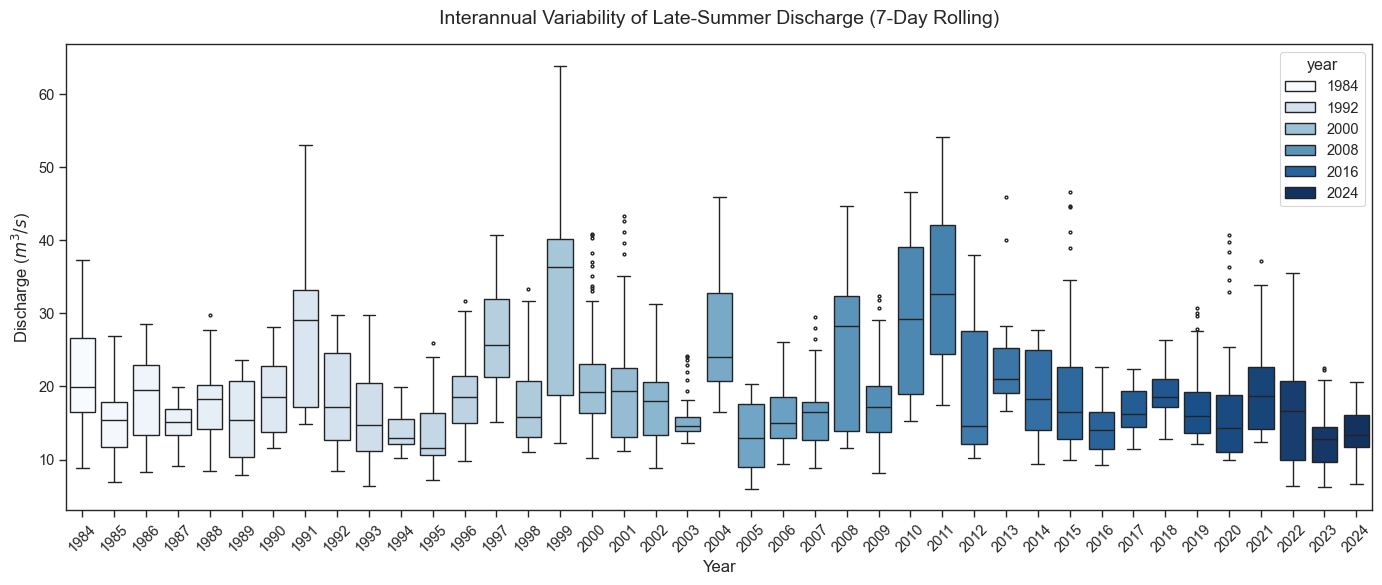

In [18]:
sns.set_context("paper", font_scale=1.2)
sns.set_style("ticks")

plt.figure(figsize=(14, 6))

# Create the boxplot
ax = sns.boxplot(data=df_melt_season, x='year', y='q_7d_roll_cms',
                 palette="Blues", hue='year', fliersize=2, linewidth=1)

plt.title('Interannual Variability of Late-Summer Discharge (7-Day Rolling)', fontsize=14, pad=15)
plt.ylabel('Discharge ($m^3/s$)', fontsize=12)
plt.xlabel('Year', fontsize=12)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Peak Flow Timing Analysis

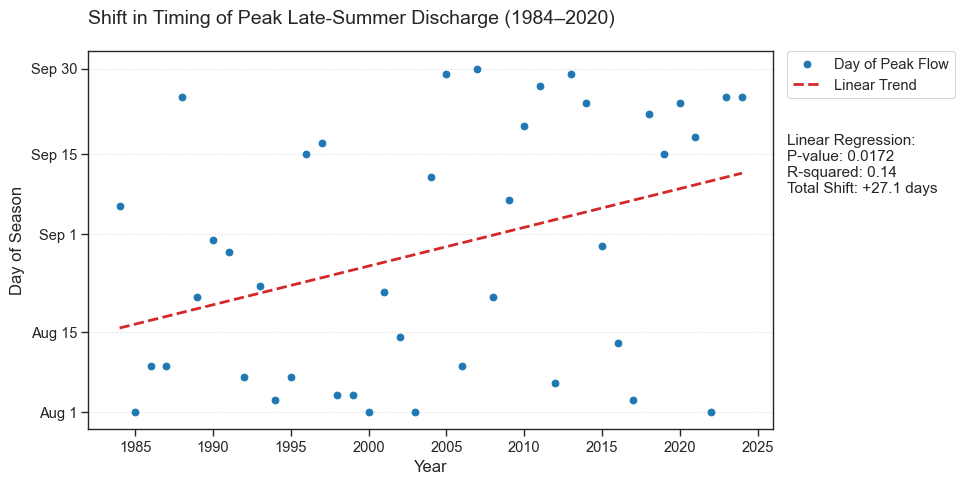

In [19]:
# calculates a sequential day number from August 1st (day 1) to September 30th (day 61). 
if 'day_of_season' not in df_melt_season.columns: 
    df_melt_season['day_of_season'] = df_melt_season.apply( lambda row: row['date'].day if row['month'] == 8 else row['date'].day + 31, axis=1 )

# find the day and value of the maximum discharge for each year
peak_days = df_melt_season.loc[df_melt_season.groupby('year')['q_cms'].idxmax()]

# regression
X = sm.add_constant(peak_days['year'])
model = sm.OLS(peak_days['day_of_season'], X).fit()
peak_days['trend'] = model.predict(X)
total_shift = peak_days['trend'].iloc[-1] - peak_days['trend'].iloc[0]

# plot
fig, ax = plt.subplots(figsize=(12, 5))

# scatter and trend line
plt.scatter(peak_days['year'], peak_days['day_of_season'], color='#1f77b4', label='Day of Peak Flow', zorder=3)
plt.plot(peak_days['year'], peak_days['trend'], color='#d62728', linestyle='--', linewidth=2, label='Linear Trend', zorder=4)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, frameon=True)

# add stats
stats_text = (f"Linear Regression:\n"
              f"P-value: {model.pvalues['year']:.4f}\n"
              f"R-squared: {model.rsquared:.2f}\n"
              f"Total Shift: +{total_shift:.1f} days")

plt.text(1.02, 0.7, stats_text, transform=ax.transAxes, fontsize=11,
         verticalalignment='center')

plt.title('Shift in Timing of Peak Late-Summer Discharge (1984–2020)', fontsize=14, loc='left', pad=20)
plt.ylabel('Day of Season', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.yticks([1, 15, 32, 46, 61], ['Aug 1', 'Aug 15', 'Sep 1', 'Sep 15', 'Sep 30'])
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()

### Seasonal Hydrograph Variability

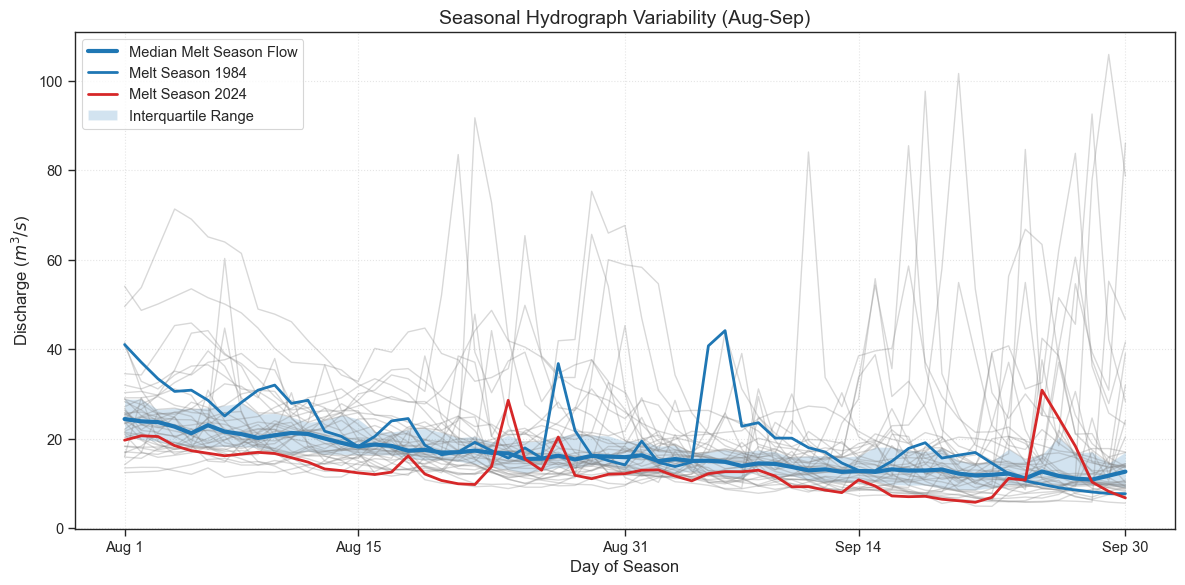

In [20]:
# calculate a sequential day number from August 1st (day 1) to September 30th (day 61).
if 'day_of_season' not in df_melt_season.columns:
    df_melt_season['day_of_season'] = df_melt_season.apply(
        lambda row: row['date'].day if row['month'] == 8 else row['date'].day + 31,
        axis=1
    )

# calculate median hydrograph across all years
median_hydrograph = df_melt_season.groupby("day_of_season")["q_cms"].median()

# plot variability
plt.figure(figsize=(12, 6))

# plot each year 
for year in df_melt_season['year'].unique():
    year_data = df_melt_season[df_melt_season['year'] == year]
    plt.plot(year_data['day_of_season'], year_data['q_cms'], color='grey', alpha=0.3, linewidth=1)

# median seasonal hydrograph
plt.plot(
    median_hydrograph.index,
    median_hydrograph.values,
    linewidth=3,
    label="Median Melt Season Flow"
)

# overlay 1984 and 2024
for yr, col in zip([1984, 2024], ['#1f77b4', '#d62728']):
    yr_data = df_melt_season[df_melt_season['year'] == yr]
    plt.plot(yr_data['day_of_season'], yr_data['q_cms'], color=col, linewidth=2, label=f'Melt Season {yr}')

# fill interquartile range
q25 = df_melt_season.groupby("day_of_season")["q_cms"].quantile(0.25)
q75 = df_melt_season.groupby("day_of_season")["q_cms"].quantile(0.75)

plt.fill_between(q25.index, q25, q75, alpha=0.2, label="Interquartile Range")

plt.title('Seasonal Hydrograph Variability (Aug-Sep)', fontsize=14)
plt.xlabel('Day of Season', fontsize=12)
plt.ylabel('Discharge ($m^3/s$)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)

tick_positions = [1, 15, 31, 45, 61]
tick_labels = ['Aug 1', 'Aug 15', 'Aug 31', 'Sep 14', 'Sep 30']
plt.xticks(tick_positions, tick_labels)

plt.tight_layout()
plt.savefig('../figures/03_Seasonal_Hydrograph_Variability.png', dpi=300, bbox_inches='tight', pad_inches=0.2)
plt.show()

## Streamflow Variability Analysis

### Statistical Stationary Testing
Stationarity is a key assumption for many time-series forecasting models, ensuring that the mean and variance remain constant over time.

- Null hypothesis: Data is non-stationary
- Alternative hypothese: Data is stationary
- Significance level = 0.05

In [21]:
# ADF test to check if the time series is stationary

# run ADF test
result = adfuller(df_melt_season['q_cms'])
p_value = result[1]
adf_stat = result[0]
critical_values = result[4]

# results
print(f"ADF Statistic: {adf_stat:.4f}")
print(f"p-value:       {p_value:.4e}") # Using scientific notation for small p-values

print("\nCritical Values:")
for key, value in critical_values.items():
    print(f"{key}: {value:.4f}")

# interpret results
if p_value < 0.05:
    print('\nReject the null hypothesis. The streamflow time series is stationary (no unit root).')
else:
    print('\nFail to reject the null hypothesis. The series is non-stationary (contains a unit root)')

ADF Statistic: -8.6953
p-value:       3.9397e-14

Critical Values:
1%: -3.4330
5%: -2.8627
10%: -2.5674

Reject the null hypothesis. The streamflow time series is stationary (no unit root).


### Time Series Decomposition

Analysis:

- Trend: Steep drop in 2021 from approximately 22 m³/s to 12 m³/s
- Seasonal: Captures consistent melt cyccle in the Aug-Sept flow
- Residual: Show large spikes in years 2020 and 2021 with values jumping up to 60 $m^3/s$. This can be caused by extreme rain events

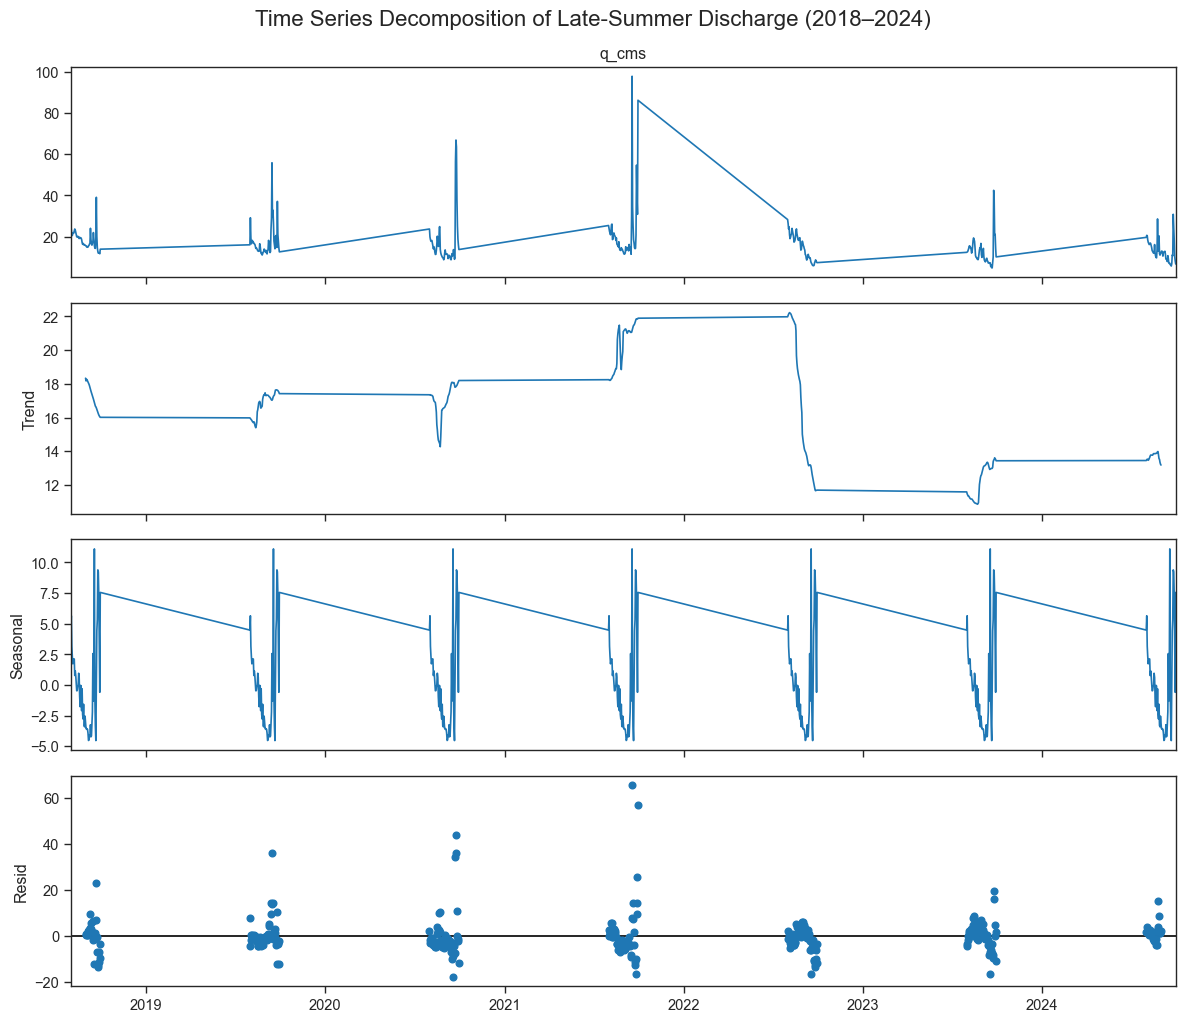

In [22]:
# get data from the past 5 years
recent_data = df_melt_season[df_melt_season['year'] >= 2018].set_index('date')['q_cms']

# perform decomposition with a period of 61 days to match season length
result = seasonal_decompose(recent_data, model='additive', period=61)

# plot
plt.rc('figure', figsize=(12, 10))
fig = result.plot()
fig.suptitle('Time Series Decomposition of Late-Summer Discharge (2018–2024)', fontsize=16, y=1.02)
plt.savefig('../figures/04_Time_Series_Decomposition_of_Discharge.png', dpi=300, bbox_inches='tight')
plt.show()

## Final Melt Season Streamflow Dataset

In [23]:
display(df_melt_season.head())
print('')
display(df_melt_season.describe())

,date,site_no,q_cfs,00060_Mean_cd,q_7d_roll_cfs,year,month,q_cms,q_7d_roll_cms,is_estimated,day_of_season
213,1984-08-01,12205000,1450.0,A,1318.571429,1984,8,41.059360,37.337723,False,1
214,1984-08-02,12205000,1310.0,A,1272.857143,1984,8,37.095008,36.043241,False,2
215,1984-08-03,12205000,1180.0,A,1257.142857,1984,8,33.413824,35.598263,False,3
216,1984-08-04,12205000,1080.0,A,1234.285714,1984,8,30.582144,34.951022,False,4
217,1984-08-05,12205000,1090.0,A,1225.714286,1984,8,30.865312,34.708306,False,5


,date,q_cfs,q_7d_roll_cfs,year,month,q_cms,q_7d_roll_cms,day_of_season
count,2501,2501.000000,2501.000000,2501.000000,2501.000000,2501.000000,2501.000000,2501.000000
mean,2004-08-30 15:13:10.243902592,660.401439,678.532815,2004.000000,8.491803,18.700455,19.213878,31.000000
min,1984-08-01 00:00:00,173.000000,211.428571,1984.000000,8.000000,4.898806,5.986981,1.000000
25%,1994-08-16 00:00:00,439.000000,471.714286,1994.000000,8.000000,12.431075,13.357439,16.000000
50%,2004-08-31 00:00:00,576.000000,614.285714,2004.000000,8.000000,16.310477,17.394606,31.000000
75%,2014-09-15 00:00:00,754.000000,794.000000,2014.000000,9.000000,21.350867,22.483539,46.000000
max,2024-09-30 00:00:00,3740.000000,2257.142857,2024.000000,9.000000,105.904832,63.915063,61.000000
std,NaN,372.891425,300.087364,11.834526,0.500033,10.559092,8.497514,17.610338


## Export


In [24]:
# export final streamflow dataset as CSV
df_melt_season.to_csv('../data/streamflow.csv', index=False)


# Key Findings

The late-summer hydrological regime of the North Fork Nooksack River (Aug–Sep) shows significant shifts in timing and stability over the 1984-2024 period.
- **Stationarity:** The ADF test confirms the melt-season discharge series is stationary (p ≈ 0.0000), indicating the data is statistically suitable for time-series modeling without further differencing.
- **Peak Flow Timing:** Regression analysis indicates a statistically significant total shift of +27.1 days in the timing of peak late-summer discharge, suggesting changes in the synchronization of glacial melt and seasonal warming.
- **Baseflow Decline:** Time-series decomposition reveals a notable drop in the "Trend" component after 2021, with baseflow levels falling from approximately 22 m³/s to 12 m³/s following extreme thermal events.
- **Residual Volatility:** Large spikes in the residuals (notably in 2020 and 2021) indicate significant discharge variability (spikes > 60 m³/s) that is not captured by seasonal patterns, likely driven by rain-on-ice events or extreme heatwaves.